In [2]:
import pandas as pd 
import sklearn as sk
import os
import pandas as pd
import numpy as np 
import sklearn
import matplotlib.pyplot as plt
import seaborn as sns 
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import RobustScaler
from sklearn.svm import SVC
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import classification_report, confusion_matrix
import scanpy as sc
import anndata as ad
import bbknn
from sklearn.decomposition import PCA
import numpy as np
import harmonypy as hm
GENE_PANEL = ["ATOH1","DLL1","DLL4","GFI1","AREG","HES1","HES5","JAG2","NOTCH1","NOTCH2","NOTCH3",
              "OLFM4","LEF1","APCDD1","WNT6","NEUROG3","NEUROD1","KRT20","NEURL1","LGR5"]
S_GENES = [
    "MCM5","PCNA","TYMS","FEN1","MCM2","MCM4","RRM1","UNG","GINS2","MCM6","CDCA7",
    "DTL","PRIM1","UHRF1","HELLS","RFC2","RPA2","NASP","RAD51AP1","GMNN","WDR76",
    "SLBP","CCNE2","UBR7","POLD3","MSH2","ATAD2","RAD51","RRM2","CDC45","CDC6",
    "EXO1","TIPIN","DSCC1","BLM","CASP8AP2","USP1","CLSPN","POLA1","CHAF1B","BRIP1",
    "E2F8"
]
G2M_GENES = [
    "HMGB2","CDK1","NUSAP1","UBE2C","BIRC5","TPX2","TOP2A","NDC80","CKS2","NUF2",
    "CKS1B","MKI67","TMPO","CENPF","TACC3","SMC4","CCNB2","CKAP2L","CKAP2","AURKB",
    "BUB1","KIF11","ANP32E","TUBB4B","GTSE1","KIF20B","HJURP","CDCA3","CDC20","TTK",
    "CDC25C","KIF2C","RANGAP1","NCAPD2","DLGAP5","CDCA2","CDCA8","ECT2","KIF23",
    "HMMR","AURKA","PSRC1","ANLN","LBR","CKAP5","CENPE","CTCF","NEK2","G2E3",
    "GAS2L3","CBX5","CENPA"
]
cycle_genes = set(S_GENES).union(set(G2M_GENES))

/usr/local/mamba/envs/bbknn_env/lib/python3.10/site-packages/louvain/__init__.py:54: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import get_distribution, DistributionNotFound
/usr/local/mamba/envs/bbknn_env/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [61]:
data_path='/mnt/cold2/snaketree/prj/PPH/local/share/data/saver_mat'
train_id=['CRC1502','CRC1620','CRC1139','CRC0322','CRC0327','CRC0542']
tratt_cercato=['cetux','CTX72h','NT','NT72h']
train=pd.DataFrame()
for file in os.listdir(data_path):
    sample_name=str.split(file,sep='_')[4]
    trattamento=str.split(file,sep='_')[5]
    if sample_name in train_id and trattamento in tratt_cercato:
        data=pd.read_csv(os.path.join(data_path,file),header=0,index_col=0)
        data=data.T
        data['sample']=sample_name
        data['cell_id']=data.index
        data['trattamento']=trattamento
        data.reset_index(drop=True,inplace=True)
        train=pd.concat([train,data])

In [62]:
train.head()

,ENSG00000000003:TSPAN6,ENSG00000000005:TNMD,ENSG00000000419:DPM1,ENSG00000000457:SCYL3,ENSG00000000460:C1orf112,ENSG00000000938:FGR,ENSG00000000971:CFH,ENSG00000001036:FUCA2,ENSG00000001084:GCLC,ENSG00000001167:NFYA,...,ENSG00000282872:C1orf232,ENSG00000282881:TMEM275,ENSG00000282936:AC004706.3,ENSG00000282988:AL031777.2,ENSG00000283039:KLF18,ENSG00000283071:LBHD2,ENSG00000283093:CENPVL2,sample,cell_id,trattamento
0,9.182038,1.290913,5.851694,4.409771,2.075592,0.215068,0.0,7.922556,6.088234,5.553882,...,0.0,0.0,0.402195,4.442139,0.0,0.0,0.0,CRC0322,AAACCCACACACCAGC.1,cetux
1,8.954556,1.236142,6.162812,4.331284,2.004544,0.202425,0.0,8.131447,6.932005,4.700702,...,0.0,0.0,0.379911,4.475017,0.0,0.0,0.0,CRC0322,AAACCCACACTGGCCA.1,cetux
2,8.430824,1.181180,6.186498,4.239364,2.220954,0.190105,0.0,8.243728,6.510044,5.097605,...,0.0,0.0,0.358051,4.430529,0.0,0.0,0.0,CRC0322,AAACCCAGTGTCTTCC.1,cetux
3,8.939527,1.116606,6.343033,4.245160,2.305453,0.196664,0.0,8.189441,6.896644,5.820109,...,0.0,0.0,0.369707,3.977334,0.0,0.0,0.0,CRC0322,AAACGAATCGAAGCCC.1,cetux
4,9.529687,1.146387,6.312496,4.169142,2.295855,0.182493,0.0,8.418498,7.457436,5.653994,...,0.0,0.0,0.344472,4.667132,0.0,0.0,0.0,CRC0322,AAACGCTGTCTGCATA.1,cetux


In [63]:
from func_NT_cetux import *
n_hvg=1500
df=train
df_clean, dup = strip_prefix_from_genes(df, meta_cols=("cell_id","sample","trattamento"), sep=":", on_duplicate="first")


# 2) AnnData + raw
adata_full = make_anndata_from_df(
    df_clean,
    cell_col="cell_id",
    sample_col="sample",
    trattamento_col="trattamento",
    set_raw=True
)

In [64]:
from func_NT_cetux import *
n_hvg=1500


# 2) AnnData + raw
#adata_full = make_anndata_from_df(df_clean, set_raw=True)

# 3) cell cycle
score_cell_cycle(adata_full)

genes_to_keep = [g for g in adata_full.var_names if g not in cycle_genes]

adata_full = adata_full[:, genes_to_keep].copy()

# 4) HVG + PCA
select_hvg_cell_ranger(adata_full, n_top_genes=n_hvg, batch_key="sample", subset=True)
scale_and_pca(adata_full, n_comps=42, max_value=10, random_state=42)
adata_base = adata_full

BEST = dict(
    n_pcs=20,          
    nwb=3,             
    trim=None,         
    leiden_res=0.3,    
    out_root="./bbknn_ALL_prova"
)


# cartella output
def safe(s): return re.sub(r"[^A-Za-z0-9_=.,+-]", "_", str(s))
outdir = os.path.join(
    BEST["out_root"],
    f"npcs={BEST['n_pcs']}__nwb={BEST['nwb']}__trim={BEST['trim']}__res={BEST['leiden_res']}"
)
os.makedirs(outdir, exist_ok=True)
sc.settings.figdir = outdir

# 5)integrazione
adx = adata_base.copy()
bbknn.bbknn(
    adx,
    batch_key="sample",
    neighbors_within_batch=BEST['nwb'],
    trim=BEST["trim"],
    n_pcs=BEST["n_pcs"]
)
sc.tl.umap(adx, min_dist=0.3, random_state=42)  # UMAP usa il grafo BBKNN
save_umap_gene_panel(adx, outdir, GENE_PANEL)
# 6)clustering (Leiden)
clu_key = f"leiden_r{BEST['leiden_res']}"
sc.tl.leiden(adx, resolution=BEST["leiden_res"], key_added=clu_key, random_state=42)

# plot rapidi &
sc.pl.umap(adx, color=["sample", clu_key], ncols=2, wspace=0.3, frameon=False,
           show=False, save="_sample+cluster.png")
if "phase" in adx.obs:
    sc.pl.umap(adx, color=["phase"], frameon=False, show=False, save="_phase.png")

saving figure to file bbknn_ALL_prova/npcs=20__nwb=3__trim=None__res=0.3/umap_genes_panel.png
saving figure to file bbknn_ALL_prova/npcs=20__nwb=3__trim=None__res=0.3/umap_sample+cluster.png
saving figure to file bbknn_ALL_prova/npcs=20__nwb=3__trim=None__res=0.3/umap_phase.png


In [65]:
data_obs=pd.DataFrame(adx.obs)

data_obs["umap_1"] = adx.obsm["X_umap"][:, 0]
data_obs["umap_2"] = adx.obsm["X_umap"][:, 1]


data_obs.to_csv(path_or_buf='bbknn_ALL_prova/npcs=20__nwb=3__trim=None__res=0.3/obs_data.csv',index=False)

In [66]:
sc.tl.rank_genes_groups(adx, groupby=clu_key, method="wilcoxon", use_raw=adx.raw is not None)
sc.pl.rank_genes_groups(adx, n_genes=25, sharey=False, show=False, save=f"_{clu_key}_top25.png")
data_marker=sc.get.rank_genes_groups_df(adx, None)

saving figure to file bbknn_ALL_prova/npcs=20__nwb=3__trim=None__res=0.3/rank_genes_groups_leiden_r0.3_leiden_r0.3_top25.png


## Confronto


In [9]:
data_kras_path='bbknn_cetux_KRAS/npcs=20__nwb=3__trim=None__res=0.3/obs_data.csv'
data_kras=pd.read_csv(data_kras_path)
# data_mixed_path='bbknn_NT_cetux_KRAS/npcs=20__nwb=3__trim=None__res=0.3/obs_data.csv'
# data_mixed=pd.read_csv(data_mixed_path)
data_kras = data_kras.reset_index(drop=True)
# data_obs  = data_obs.reset_index(drop=True)

# kras_conf = pd.merge(
#     data_obs,
#     data_kras,
#     on="uid",
#     how="inner",              # tiene solo uid comuni
#     suffixes=("all", "_only_kras")  # aggiunge suffix alle colonne duplicate di data_kras
# )

In [10]:
data_kras['trattamento'].unique()

array(['cetux'], dtype=object)

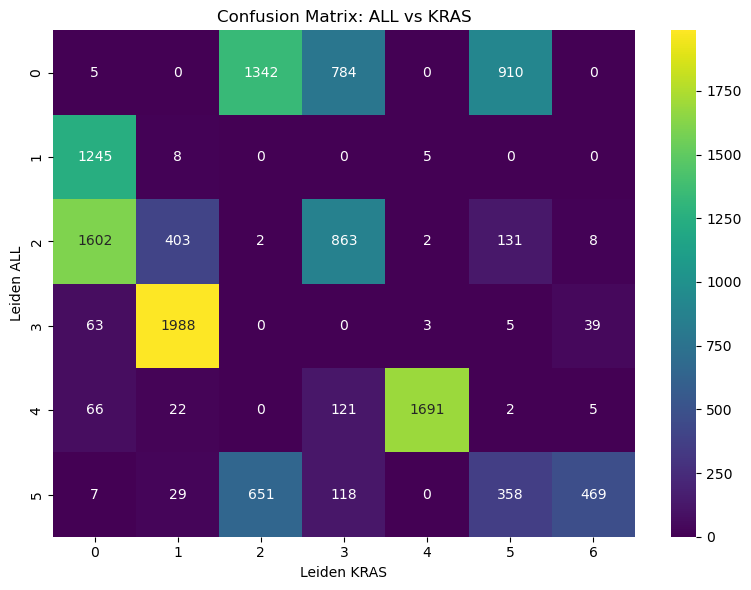

In [45]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# matrice di confusione
conf_mat = pd.crosstab(
    kras_conf["leiden_r0.3all"],
    kras_conf["leiden_r0.3_only_kras"]
)

plt.figure(figsize=(8,6))

sns.heatmap(
    conf_mat,
    annot=True,
    fmt="d",
    cmap="viridis"
)

plt.xlabel("Leiden KRAS")
plt.ylabel("Leiden ALL")
plt.title("Confusion Matrix: ALL vs KRAS")

plt.tight_layout()
plt.show()

In [46]:
data_cetux_path='bbknn_cetux_KRAS/npcs=20__nwb=3__trim=None__res=0.3/prediction_wt_cetux/prediction_wt_cetux.csv'
data_cetux=pd.read_csv(data_cetux_path)
# data_mixed_path='bbknn_NT_cetux_KRAS/npcs=20__nwb=3__trim=None__res=0.3/obs_data.csv'
# data_mixed=pd.read_csv(data_mixed_path)
data_cetux = data_cetux.reset_index(drop=True)
data_obs  = data_obs.reset_index(drop=True)

kras_conf = pd.merge(
    data_obs,
    data_cetux,
    on="uid",
    how="inner",              # tiene solo uid comuni
    suffixes=("all", "pred")  # aggiunge suffix alle colonne duplicate di data_kras
)

,cell_idall,sampleall,trattamentoall,uid,S_score,G2M_score,phase,leiden_r0.3,samplepred,cell_idpred,trattamentopred,pred_cluster,pred_cluster_filt,accepted,margin,max_prob
0,AAACCCACACACCAGC.1,CRC0322,cetux,CRC0322cetux|AAACCCACACACCAGC.1|cetux,-1.366692,-2.322153,G1,1,CRC0322,AAACCCACACACCAGC.1,cetux,0,0,True,0.406667,0.606667
1,AAACCCACACTGGCCA.1,CRC0322,cetux,CRC0322cetux|AAACCCACACTGGCCA.1|cetux,-1.270649,-2.246790,G1,1,CRC0322,AAACCCACACTGGCCA.1,cetux,0,0,True,0.360000,0.580000
2,AAACCCAGTGTCTTCC.1,CRC0322,cetux,CRC0322cetux|AAACCCAGTGTCTTCC.1|cetux,-1.485403,-2.431747,G1,1,CRC0322,AAACCCAGTGTCTTCC.1,cetux,0,0,True,0.440000,0.610000
3,AAACGAATCGAAGCCC.1,CRC0322,cetux,CRC0322cetux|AAACGAATCGAAGCCC.1|cetux,-1.470630,-2.607085,G1,1,CRC0322,AAACGAATCGAAGCCC.1,cetux,0,0,True,0.250000,0.486667
4,AAACGCTGTCTGCATA.1,CRC0322,cetux,CRC0322cetux|AAACGCTGTCTGCATA.1|cetux,-1.369107,-2.606674,G1,1,CRC0322,AAACGCTGTCTGCATA.1,cetux,0,0,True,0.223333,0.506667
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8432,TTTGATCCAGGTGAGT.1,CRC0542,CTX72h,CRC0542CTX72h|TTTGATCCAGGTGAGT.1|CTX72h,-1.634883,-2.072892,G1,4,CRC0542,TTTGATCCAGGTGAGT.1,CTX72h,4,4,True,0.086667,0.413333
8433,TTTGGAGAGGCGAACT.1,CRC0542,CTX72h,CRC0542CTX72h|TTTGGAGAGGCGAACT.1|CTX72h,-1.558105,-1.428510,G1,4,CRC0542,TTTGGAGAGGCGAACT.1,CTX72h,4,4,True,0.100000,0.363333
8434,TTTGGTTAGGATGCGT.1,CRC0542,CTX72h,CRC0542CTX72h|TTTGGTTAGGATGCGT.1|CTX72h,-1.353877,-1.832609,G1,1,CRC0542,TTTGGTTAGGATGCGT.1,CTX72h,0,0,True,0.343333,0.550000
8435,TTTGGTTAGGGAACAA.1,CRC0542,CTX72h,CRC0542CTX72h|TTTGGTTAGGGAACAA.1|CTX72h,-1.932496,-2.039602,G1,1,CRC0542,TTTGGTTAGGGAACAA.1,CTX72h,0,0,True,0.213333,0.450000


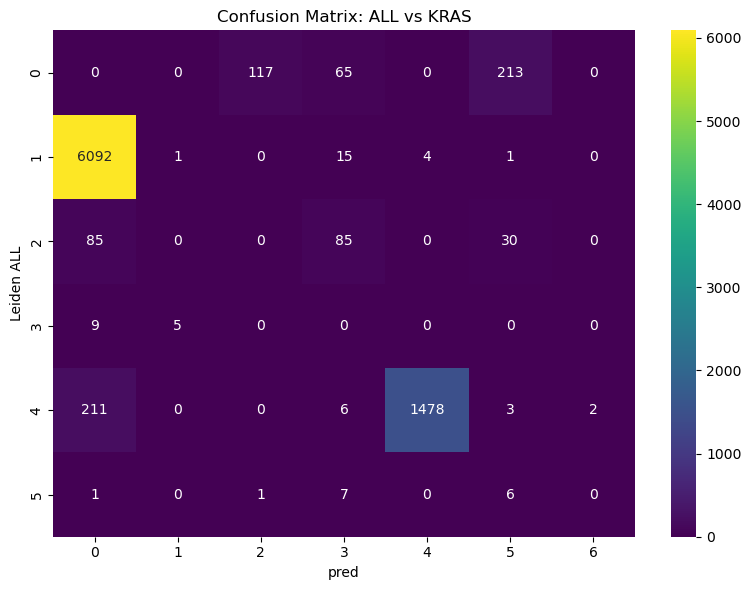

In [48]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# matrice di confusione
conf_mat = pd.crosstab(
    kras_conf["leiden_r0.3"],
    kras_conf["pred_cluster"]
)

plt.figure(figsize=(8,6))

sns.heatmap(
    conf_mat,
    annot=True,
    fmt="d",
    cmap="viridis"
)

plt.xlabel("pred")
plt.ylabel("Leiden ALL")
plt.title("Confusion Matrix: ALL vs cetux WT")

plt.tight_layout()
plt.show()

In [51]:
data_nt_path='bbknn_cetux_KRAS/npcs=20__nwb=3__trim=None__res=0.3/prediction_wt_nt/prediction_wt_nt.csv'
data_nt=pd.read_csv(data_nt_path)
# data_mixed_path='bbknn_NT_cetux_KRAS/npcs=20__nwb=3__trim=None__res=0.3/obs_data.csv'
# data_mixed=pd.read_csv(data_mixed_path)
data_cetux = data_nt.reset_index(drop=True)
data_obs  = data_obs.reset_index(drop=True)

kras_conf = pd.merge(
    data_obs,
    data_nt,
    on="uid",
    how="inner",              # tiene solo uid comuni
    suffixes=("all", "pred")  # aggiunge suffix alle colonne duplicate di data_kras
)

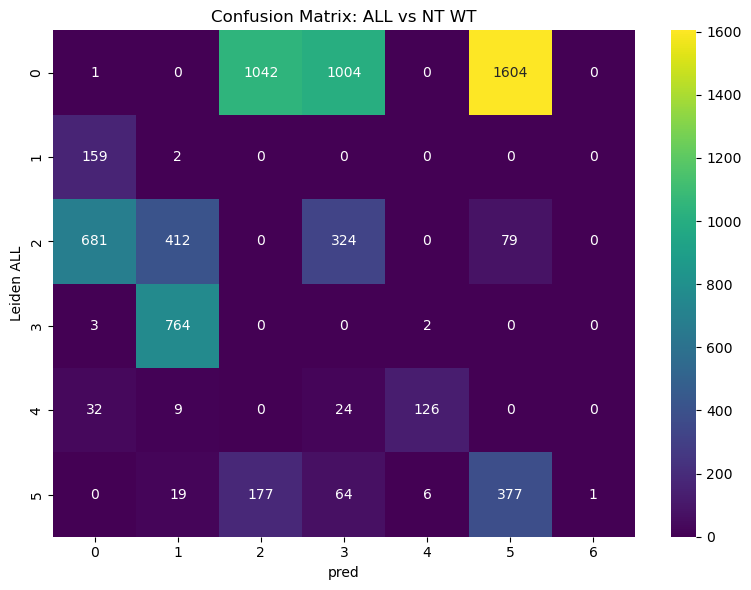

In [53]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# matrice di confusione
conf_mat = pd.crosstab(
    kras_conf["leiden_r0.3"],
    kras_conf["pred_cluster"]
)

plt.figure(figsize=(8,6))

sns.heatmap(
    conf_mat,
    annot=True,
    fmt="d",
    cmap="viridis"
)

plt.xlabel("pred")
plt.ylabel("Leiden ALL")
plt.title("Confusion Matrix: ALL vs NT WT")

plt.tight_layout()
plt.show()